In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from data_preprocessing import load_dataset

dataset_easy = load_dataset("datasets/E4A_1-1.data")
dataset_medium = load_dataset("datasets/E4A_2-8.data")
dataset_hard = load_dataset("datasets/E4A_9-64.data")

Dataset E4A_1-1.data cargado con 1000 muestras.
Dataset E4A_2-8.data cargado con 1000 muestras.
Dataset E4A_9-64.data cargado con 763 muestras.


In [3]:
from models.CLPTransformer import CLPTransformer

# Parámetros del modelo
blocks_dim = 8
action_dim = 5
placed_dim = 4
d_model = 32
nhead = 4
num_layers = 2
dropout = 0.1

# Crear modelo
model = CLPTransformer(
    block_dim=blocks_dim,
    action_dim=action_dim,
    placed_dim=placed_dim,
    d_model=d_model,
    nhead=nhead,
    num_layers=num_layers,
    dropout=dropout
)

In [4]:
from training import train

epochs = 3
datasets = [dataset_easy, dataset_medium, dataset_hard]
train_size = 200
train_weights = [1, 1, 1]
test_size = 100
test_weights = [1, 1, 1]
batch_size = 32
learning_rate = 1e-4
seed = 42

stats = train(model, epochs, datasets, train_size, train_weights, test_size, test_weights, batch_size, learning_rate, seed)

ℹ️ Usando dispositivo: cpu
ℹ️ Iniciando fase: 1/3
Epoch 1/3 - Train Loss: 4.1585, Train Accuracy: 1.00% - Val Loss: 4.1582, Val Accuracy: 30.30%
    Test Set: E4A_1-1.data - Val Loss: 4.1582, Val Accuracy: 30.30%
    Test Set: E4A_2-8.data - Val Loss: 4.1584, Val Accuracy: 6.06%
    Test Set: E4A_9-64.data - Val Loss: 4.1590, Val Accuracy: 0.00%
    Weighted - Val Loss: 4.1585, Val Accuracy: 12.12%
Epoch 2/3 - Train Loss: 4.1584, Train Accuracy: 1.50% - Val Loss: 4.1579, Val Accuracy: 33.33%
    Test Set: E4A_1-1.data - Val Loss: 4.1579, Val Accuracy: 33.33%
    Test Set: E4A_2-8.data - Val Loss: 4.1582, Val Accuracy: 6.06%
    Test Set: E4A_9-64.data - Val Loss: 4.1589, Val Accuracy: 0.00%
    Weighted - Val Loss: 4.1584, Val Accuracy: 13.13%
Epoch 3/3 - Train Loss: 4.1581, Train Accuracy: 3.00% - Val Loss: 4.1576, Val Accuracy: 39.39%
    Test Set: E4A_1-1.data - Val Loss: 4.1576, Val Accuracy: 39.39%
    Test Set: E4A_2-8.data - Val Loss: 4.1580, Val Accuracy: 6.06%
    Test Set: E4

In [5]:
from training import save_model

model_name = "CLPTransformer"
save_model(model, model_name)

✅ Modelo guardado en /home/oscar/CLP-Framework/models/CLPTransformer.pth


In [6]:
from training import load_model

model = load_model(CLPTransformer, model_name)

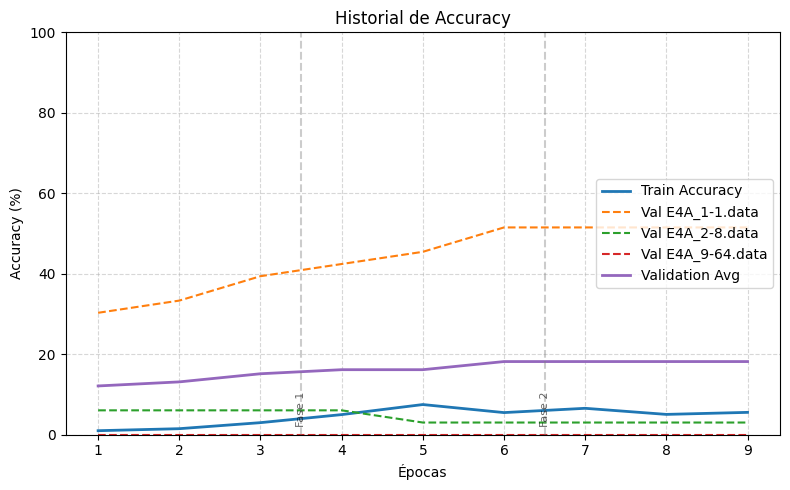

In [7]:
stats.plot()